# Iris Species Classification

## Exploratory Notebook Sandbox

**Purpose:** This notebook is the data scientist's *lab bench* — an interactive sandbox for exploring data, debugging modules, and inspecting intermediate pipeline states.

**Important:** This notebook runs entirely in memory. It does **not** write production artifacts to disk. The only entry point authorised to write `clean.csv`, `model.joblib`, and `predictions.csv` is `src/main.py`.

### A) Environment setup and imports

**Learning intent:** We use `%autoreload` so that any changes you make to a `src/` module are immediately reflected in the notebook without restarting the kernel. This is the correct way to develop modules interactively.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Ensure the repo root is on the Python path so src/ modules can be imported
PROJECT_ROOT = Path(os.getcwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/ricardo/Documents/Learning_&_Development/master_business_analytics/term_2/ML_Operations/sessions/session1-kickoff


### B) Sandbox configuration

**Guideline:** All parameters live here at the top of the notebook — never hardcoded inside cells. This mirrors the SETTINGS dict in `main.py`. In a later session these will move to `config.yaml`.

In [3]:
SETTINGS = {
    "is_example_config": True,
    "problem_type": "classification",
    "random_seed": 42,
    "test_size": 0.2,
    "target_column": "species",
    "data": {
        "source": "seaborn",
        "dataset_name": "iris",
        "processed": "data/processed/clean.csv",
    },
    "cleaning": {},
    "paths": {
        "raw_data": "data/raw/iris.csv",
        "clean_data": "data/processed/clean.csv",
        "model": "models/model.joblib",
        "predictions": "reports/predictions.csv",
    },
    "features": {
        "quantile_bin": ["sepal_length", "sepal_width", "petal_length", "petal_width"],
        "categorical_onehot": [],
        "numeric_passthrough": [],
        "n_bins": 3,
    },
}

print("SETTINGS loaded.")

SETTINGS loaded.


### 1) Load raw data (`src.load_data`)

**Educational note:** We call `load_data(SETTINGS)` from our module rather than writing `sns.load_dataset()` inline. The module encapsulates the loading logic — if the data source ever changes (e.g. from Seaborn to a CSV file), we only change it in one place.

In [4]:
from src.load_data import load_data

df_raw = load_data(SETTINGS)
print("df_raw.shape:", df_raw.shape)
df_raw.head()

df_raw.shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### 2) Focused EDA checks

**Goal:** Quickly verify the raw data looks as expected before passing it to any module. Check for missing values, class balance, and feature distributions.

In [5]:
print("Missing values:")
print(df_raw.isnull().sum())

print("\nClass distribution:")
print(df_raw[SETTINGS["target_column"]].value_counts())

Missing values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


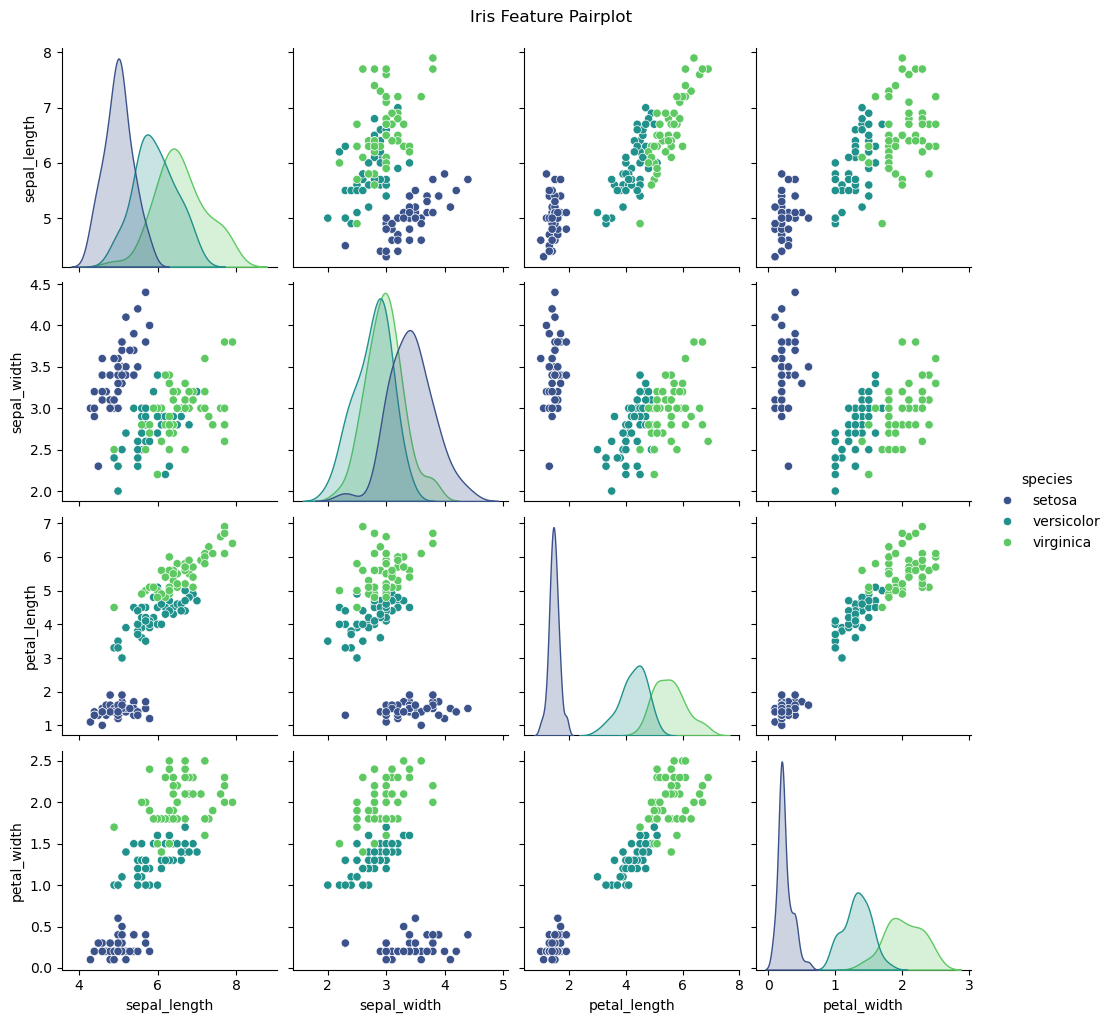

In [6]:
sns.pairplot(df_raw, hue=SETTINGS["target_column"], palette="viridis")
plt.suptitle("Iris Feature Pairplot", y=1.02)
plt.show()

### 3) Clean data (`src.clean_data`)

**Educational note:** `clean_data()` is responsible for enforcing column names, data types, and removing duplicates. We call the module here — we do not write cleaning logic inline in this notebook.

In [7]:
from src.clean_data import clean_data

df_clean = clean_data(df_raw, SETTINGS)
print("df_clean.shape:", df_clean.shape)
df_clean.head()

df_clean.shape: (149, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### 4) Didactic check: what changed after cleaning

**Goal:** Make the cleaning step transparent — show what columns exist before and after.

In [8]:
raw_cols = set(df_raw.columns)
clean_cols = set(df_clean.columns)

print("Columns added:", clean_cols - raw_cols)
print("Columns removed:", raw_cols - clean_cols)
print("Columns unchanged:", raw_cols & clean_cols)
print("\nData types after cleaning:")
print(df_clean.dtypes)

Columns added: set()
Columns removed: set()
Columns unchanged: {'petal_length', 'sepal_width', 'petal_width', 'sepal_length', 'species'}

Data types after cleaning:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


### 5b) Validate data (security gate)

**Educational note:** `validate_dataframe()` is a fail-fast security gate. If the data is empty or missing required columns, the pipeline stops here. This prevents wasting time training on broken data.

In [9]:
from src.validate import validate_dataframe

required_columns = (
    [SETTINGS["target_column"]]
    + SETTINGS["features"]["quantile_bin"]
    + SETTINGS["features"]["categorical_onehot"]
    + SETTINGS["features"]["numeric_passthrough"]
)
required_columns = list(dict.fromkeys(required_columns))  # remove duplicates

validate_dataframe(df=df_clean, required_columns=required_columns)
print("Validation passed — data is safe to use.")

[validate.validate_dataframe] Validating dataframe
Validation passed — data is safe to use.


### 5) Validate data (`src.validate`)

**Educational note:** `validate_dataframe()` is a fail-fast security gate. If the data doesn't meet the expected schema — missing columns, empty DataFrame, or columns with >50% nulls — the pipeline stops here before any expensive computation begins. This prevents silent failures downstream.

In [10]:
from src.validate import validate_dataframe

required_columns = (
    [SETTINGS["target_column"]]
    + SETTINGS["features"]["quantile_bin"]
    + SETTINGS["features"]["categorical_onehot"]
    + SETTINGS["features"]["numeric_passthrough"]
)

validate_dataframe(df_clean, required_columns)
print("Validation passed — data is safe to use.")

[validate.validate_dataframe] Validating dataframe
Validation passed — data is safe to use.


### 5) Leakage gate: train/test split

**Educational note:** We split the data BEFORE building the feature recipe. This is the key mechanism that prevents data leakage — the preprocessor will only ever see training data when it fits.

In [11]:
X = df_clean.drop(columns=[SETTINGS["target_column"]])
y = df_clean[SETTINGS["target_column"]]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=SETTINGS["test_size"],
    random_state=SETTINGS["random_seed"]
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

X_train: (119, 4), X_test: (30, 4)
y_train: (119,), y_test: (30,)


### 6) Build the feature recipe (`src.features`)

**Educational note:** `get_feature_preprocessor()` returns an UNFITTED ColumnTransformer — the recipe, not the result. It will only be fitted on `X_train` inside `train_model()`, never on the full dataset.

In [12]:
from src.features import get_feature_preprocessor

feat = SETTINGS["features"]

preprocessor = get_feature_preprocessor(
    quantile_bin_cols=feat["quantile_bin"],
    categorical_onehot_cols=feat["categorical_onehot"],
    numeric_passthrough_cols=feat["numeric_passthrough"],
    n_bins=feat["n_bins"]
)

print("Preprocessor recipe (unfitted):")
print(preprocessor)

[features] Building feature preprocessor recipe (unfitted).
[features] Recipe built with 1 transformer group(s).
Preprocessor recipe (unfitted):
ColumnTransformer(transformers=[('quantile_bin',
                                 KBinsDiscretizer(encode='ordinal', n_bins=3),
                                 ['sepal_length', 'sepal_width', 'petal_length',
                                  'petal_width'])])


### 7) Train (`src.train`)

**Educational note:** `train_model()` receives the unfitted preprocessor and fits it on `X_train` only. It returns a fully fitted sklearn Pipeline that bundles preprocessing + the RandomForestClassifier together into a single deployable artifact.

In [13]:
from src.train import train_model

model_pipeline = train_model(
    X_train=X_train,
    y_train=y_train,
    preprocessor=preprocessor,
    problem_type=SETTINGS["problem_type"]
)

print("Model pipeline trained successfully.")
print(model_pipeline)

[train] Training model. Problem type: classification
[train] X_train shape: (119, 4), y_train shape: (119,)
[train] Model training complete.
Model pipeline trained successfully.
Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('quantile_bin',
                                                  KBinsDiscretizer(encode='ordinal',
                                                                   n_bins=3),
                                                  ['sepal_length',
                                                   'sepal_width',
                                                   'petal_length',
                                                   'petal_width'])])),
                ('model', RandomForestClassifier(random_state=42))])


### 8) Evaluate (`src.evaluate`)

**Educational note:** We evaluate on `X_test` — data the model has never seen. This gives us an honest estimate of real-world performance.

In [14]:
from src.evaluate import evaluate_model

score = evaluate_model(
    model=model_pipeline,
    X_test=X_test,
    y_test=y_test,
    problem_type=SETTINGS["problem_type"]
)

print(f"Test weighted F1: {score:.4f}")

[ evaluate.py ] Starting model evaluation...
[ evaluate.py ] Predictions generated for 30 samples.
[ evaluate.py ] F1 Score (weighted): 0.9664
Test weighted F1: 0.9664


### 9) Inference demo (`src.infer`)

**Educational note:** `run_inference()` applies the trained pipeline to new, unseen data. Here we use a small sample from `X_test` to simulate what a real prediction request would look like.

In [15]:
from src.infer import run_inference

X_sample = X_test.sample(n=5, random_state=SETTINGS["random_seed"])

predictions = run_inference(model_pipeline, X_sample)

print("Sample predictions:")
print(predictions)

Sample predictions:
     prediction
101   virginica
56   versicolor
127   virginica
69   versicolor
68   versicolor


---

### Summary

This notebook demonstrated the full pipeline interactively:

1. `load_data` — loaded the Iris dataset
2. `clean_data` — enforced schema and types
3. `validate` — passed the security gate
4. `features` — built the preprocessing recipe (unfitted)
5. `train` — fitted the pipeline on training data only
6. `evaluate` — measured performance on unseen test data
7. `infer` — ran predictions on new samples

To run the full automated pipeline and generate production artifacts, use:
```
python -m src.main
```